In [2]:
import os
import PIL
import exifread
import lxml.etree as etree
import numpy as np
import pandas as pd
import slidingwindow
import skimage.color
import skimage.io
import cv2

from PIL import Image
import rasterio

In [1]:
## import pre-built function
from src.torchgeo_p import AGB_Reforest
from pathlib import Path

In [17]:
ds = AGB_Reforest(
    root = 'dataset',
    metadata_path = 'mapping/final_dataset.csv'
)

In [18]:
ds.__len__()

100

In [5]:
ds.__getitem__(0)

{'image': tensor([[[106., 132., 148.,  ..., 197., 182., 145.],
          [119., 149., 148.,  ..., 179., 160., 142.],
          [125., 119., 113.,  ..., 161., 147., 147.],
          ...,
          [255., 255., 255.,  ..., 196., 199., 197.],
          [255., 255., 255.,  ..., 199., 207., 222.],
          [255., 255., 255.,  ..., 173., 171., 168.]],
 
         [[125., 140., 156.,  ..., 156., 141., 110.],
          [140., 167., 164.,  ..., 144., 122., 105.],
          [154., 141., 133.,  ..., 128., 108., 108.],
          ...,
          [255., 255., 255.,  ..., 202., 209., 206.],
          [255., 255., 255.,  ..., 203., 219., 229.],
          [255., 255., 255.,  ..., 186., 187., 183.]],
 
         [[ 50.,  71.,  80.,  ..., 134., 121.,  92.],
          [ 61.,  91.,  86.,  ..., 125., 105.,  90.],
          [ 76.,  72.,  60.,  ..., 107.,  89.,  93.],
          ...,
          [255., 255., 255.,  ..., 100., 100.,  95.],
          [255., 255., 255.,  ..., 109., 109., 111.],
          [255., 255.,

In [6]:
ds.files

[PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_10_1500_0_2500_1000.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_11_1500_750_2500_1750.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_12_1500_1500_2500_2500.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_15_2250_0_3250_1000.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_16_2250_750_3250_1750.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_17_2250_1500_3250_2500.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_18_2250_2250_3250_3250.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_20_3000_0_4000_1000.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_21_3000_750_4000_1750.png'),
 PosixPath('new_data/tiles/Carlos Vera Guevara RGB_3_0_830

Total boxes processed: 15


/home/camarada/venv/torch/.venv/lib/python3.13/site-packages/IPython/core/events.py:96: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/home/camarada/venv/torch/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


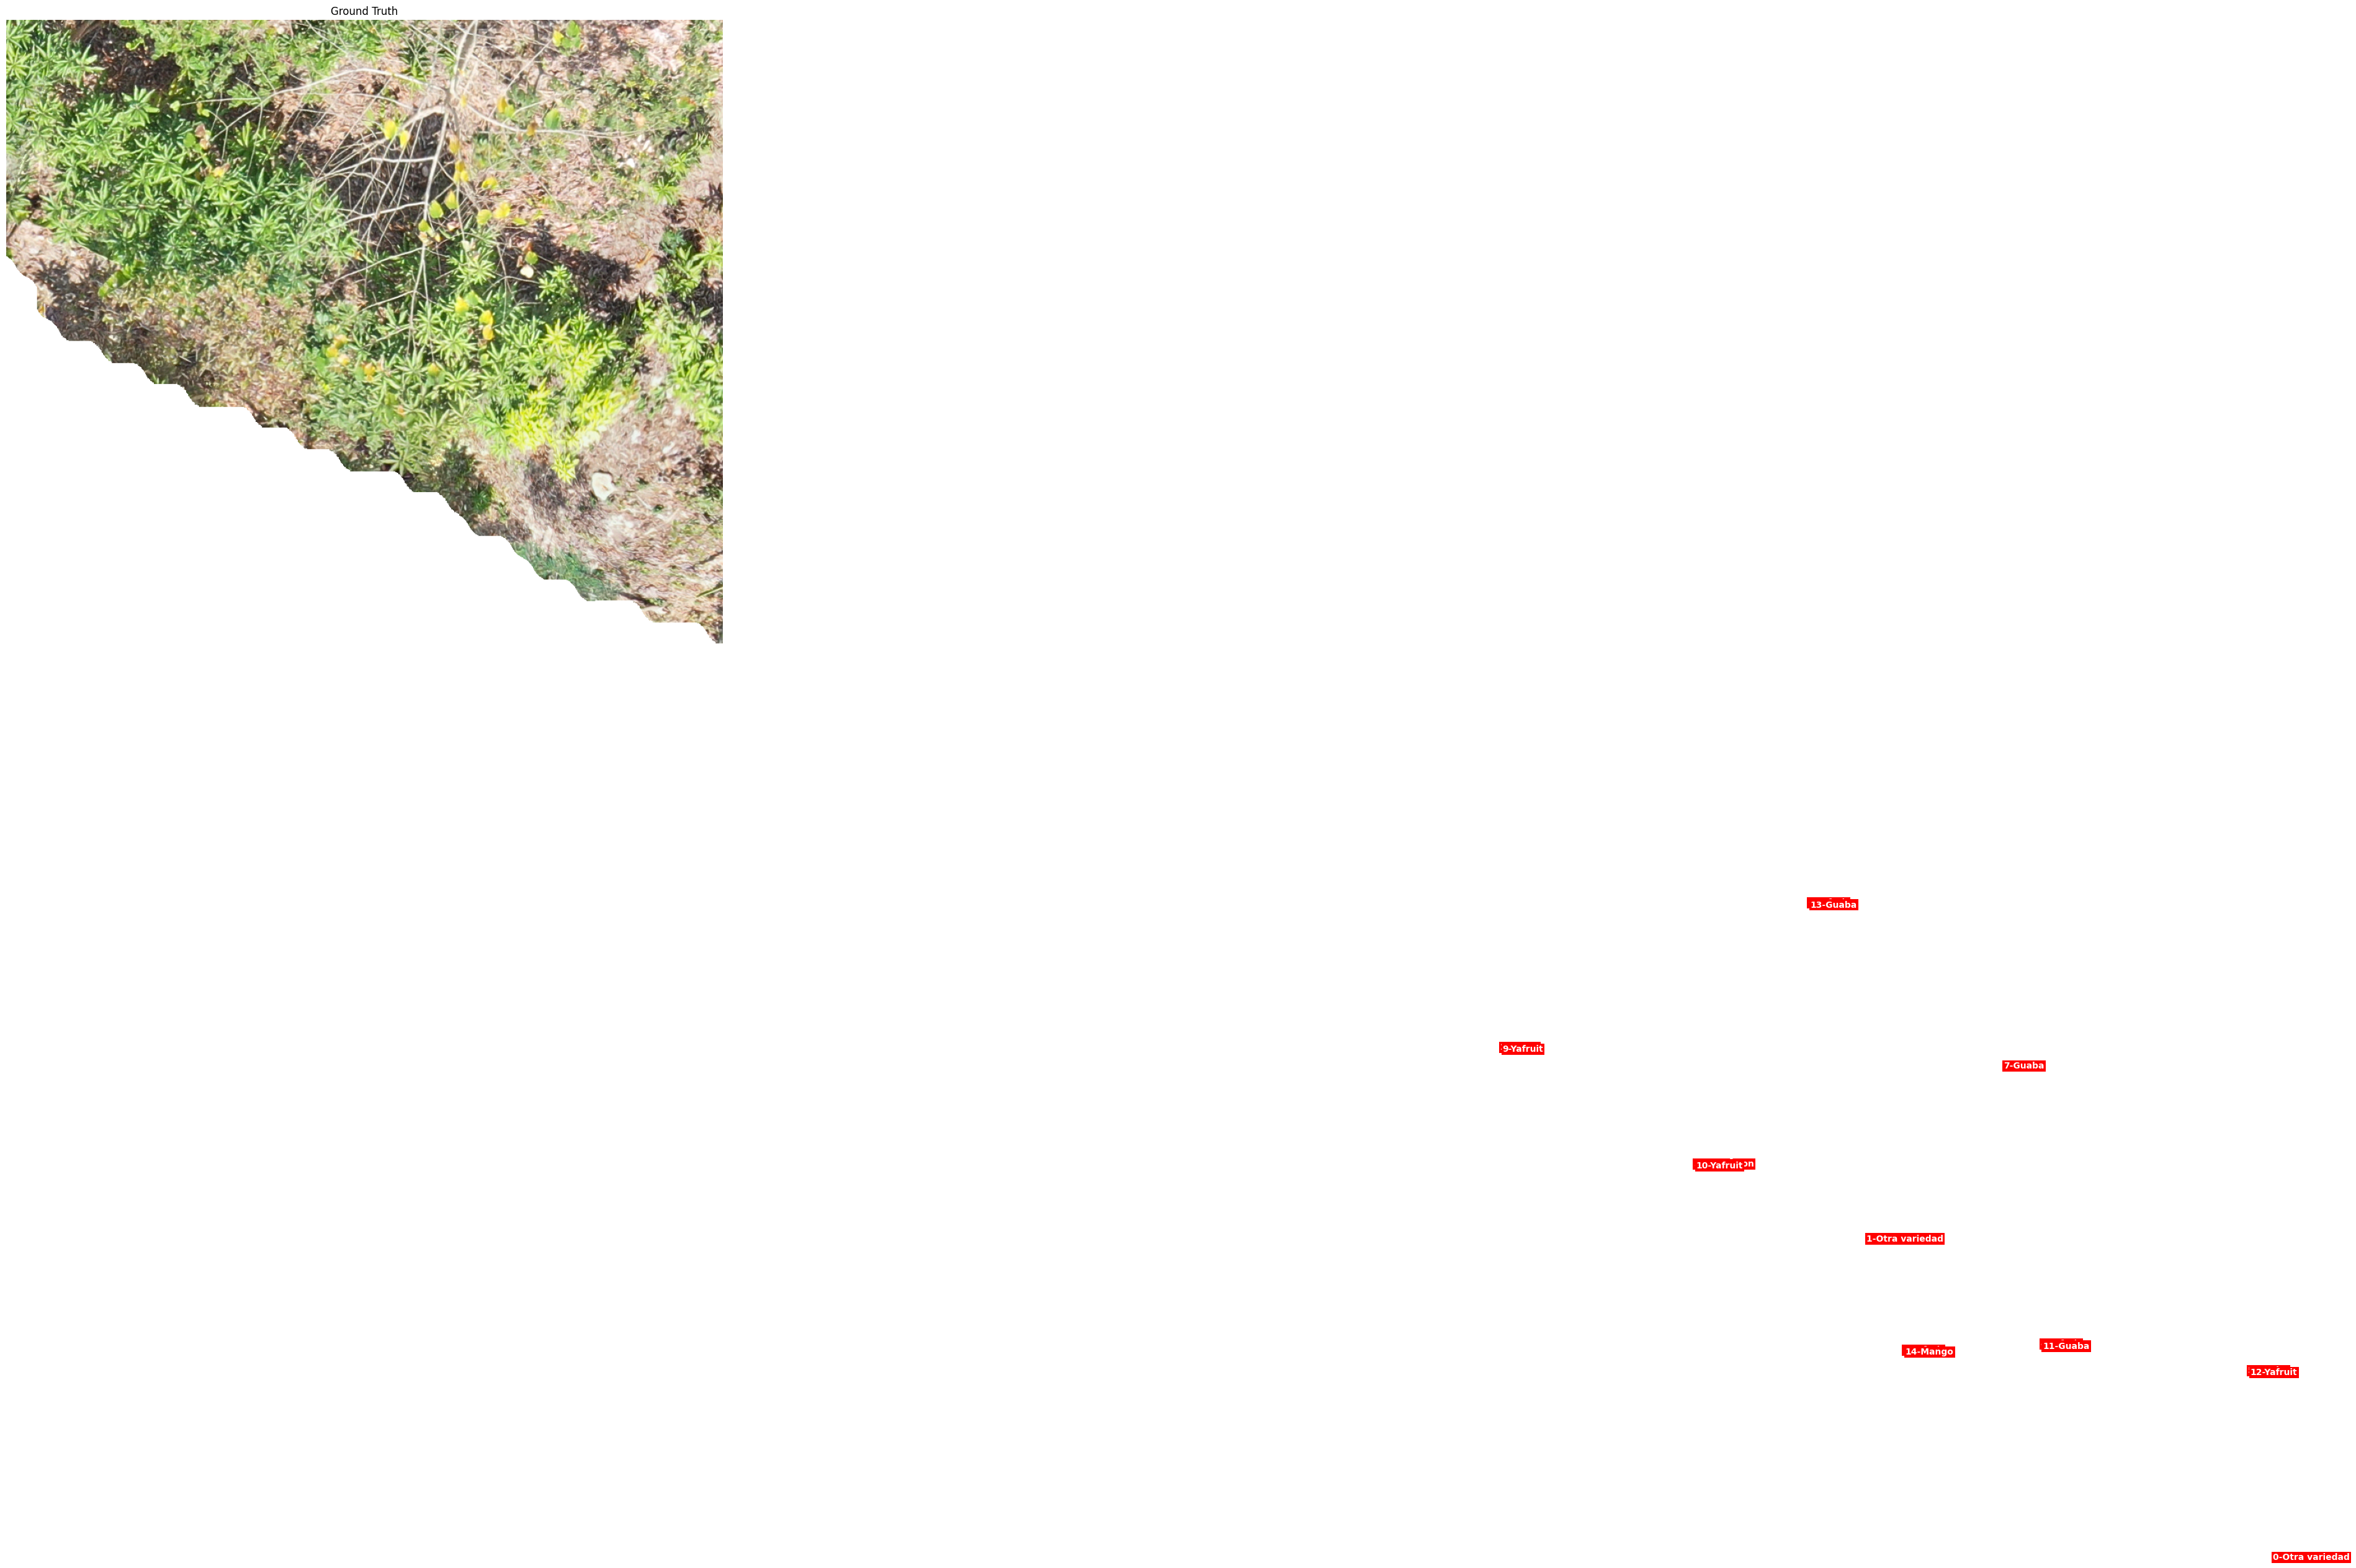

In [11]:
fig = ds.plot2(sample = ds.__getitem__(5),
        figsize = (20,15))

In [9]:
import glob
sorted(glob.glob(os.path.join(ds.root, 'tiles', '*.png')))

['new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_10_1500_0_2500_1000.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_11_1500_750_2500_1750.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_12_1500_1500_2500_2500.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_15_2250_0_3250_1000.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_16_2250_750_3250_1750.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_17_2250_1500_3250_2500.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_18_2250_2250_3250_3250.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_20_3000_0_4000_1000.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_21_3000_750_4000_1750.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_tile_22_3000_1500_4000_2500.png',
 'new_data/tiles/Carlos Vera Guevara RGB_3_0_8305_4000_12305_t

In [17]:
ds.annot_df.columns

Index(['img_path', 'xmin', 'ymin', 'xmax', 'ymax', 'score', 'img_name',
       'tile_index', 'tile_xmin', 'tile_ymin', 'tile_xmax', 'tile_ymax', 'x',
       'y', 'Xmin', 'Ymin', 'Xmax', 'Ymax', 'X_d', 'Y_d', 'lon_d', 'lat_d',
       'is_musacea_d', 'is_banana', 'ground_index', 'name', 'lat_g', 'lon_g',
       'diameter', 'height', 'year', 'plot_id', 'tree_id', 'is_musacea_g',
       'site', 'X_g', 'Y_g', 'updated diameter', 'group', 'updated height',
       'AGB', 'carbon', 'id', 'original_img_path', 'new_tile_index',
       'new_tile_xmin', 'new_tile_ymin', 'new_tile_xmax', 'new_tile_ymax',
       'xmin_tile', 'ymin_tile', 'xmax_tile', 'ymax_tile', 'x_tile', 'y_tile'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import  Stardan

0     13.228711
1      5.444228
2     18.932985
3     13.228711
4      5.444228
        ...    
92     7.788271
93     7.702971
94     5.444228
95     5.444228
96     7.788271
Name: AGB, Length: 97, dtype: float64

In [23]:
!uv pip install scikit-learn

Using Python 3.13.11 environment at: /home/camarada/venv/torch/.venv
Resolved 5 packages in 297ms                                         
Installed 3 packages in 300ms                               
 + joblib==1.5.3
 + scikit-learn==1.8.0
 + threadpoolctl==3.6.0


In [3]:
import pandas as pd

In [4]:
dff = pd.read_csv('/home/camarada/Documents/CDE/3-semester/DeepLearning/ReforesTree/dataset/mapping/final_dataset.csv')

In [5]:
print( dff['AGB'].mean(),dff['AGB'].std() )

13.041778827462792 54.50532195865228


In [6]:
nn = (dff['AGB'].values - dff['AGB'].mean()) / (dff['AGB'].std())

In [11]:
(nn[0]*dff['AGB'].std()) + dff['AGB'].mean()

np.float64(4.2932999886110075)

In [10]:
dff['AGB'].values[0]

np.float64(4.293299988611008)

In [4]:
dff['AGB'].std()

np.float64(54.50532195865228)

In [10]:
nn.mean(), nn.std()

(np.float64(1.8285466071458723e-17), np.float64(0.9998927671435448))

In [13]:
def visualize_processed_patches( image, bboxes, patch_size=1000):
    """Helper method to visualize which patches are being processed."""
    h, w = image.shape[1], image.shape[2]
    
    patches_needed = set()
    for bbox in bboxes:
        x1, y1, x2, y2 = bbox.int()
        patch_x_start = max(0, (x1.item() // patch_size) * patch_size)
        patch_x_end = min(w, ((x2.item() // patch_size) + 1) * patch_size)
        patch_y_start = max(0, (y1.item() // patch_size) * patch_size)
        patch_y_end = min(h, ((y2.item() // patch_size) + 1) * patch_size)
        
        for i in range(patch_y_start, patch_y_end, patch_size):
            for j in range(patch_x_start, patch_x_end, patch_size):
                patches_needed.add((i, j))
    
    total_patches = (h // patch_size + 1) * (w // patch_size + 1)
    print(f"Processing {len(patches_needed)}/{total_patches} patches ({len(patches_needed)/total_patches*100:.1f}%)")
    
    return patches_needed

In [19]:
num = 4
image = ds.__getitem__(num)['image']
bboxes = ds.__getitem__(num)['bbox_xyxy']

visualize_processed_patches(image, bboxes, 1000)

Processing 14/25 patches (56.0%)


{(0, 0),
 (0, 1000),
 (0, 2000),
 (1000, 0),
 (1000, 1000),
 (1000, 2000),
 (1000, 3000),
 (2000, 0),
 (2000, 1000),
 (2000, 2000),
 (2000, 3000),
 (3000, 0),
 (3000, 1000),
 (3000, 2000)}

In [20]:
bboxes

tensor([[2396.0706, 3135.1047, 2592.9263, 3313.9502],
        [ 662.2983, 2563.2773,  845.6776, 2747.5024],
        [ 351.9327, 2750.6089,  552.4182, 2963.6626],
        [ 895.2344, 1797.8645, 1085.4354, 1974.7766],
        [2715.2812,  173.4958, 2906.7031,  367.5760],
        [1221.7706, 1487.0234, 1452.2559, 1728.9442],
        [2451.9365,  722.7057, 2654.8826,  903.9874],
        [2128.1162,    5.0588, 2366.7942,  119.3938],
        [   5.6633,  608.1386,  199.1162,  922.6133],
        [2399.0706, 3138.1047, 2590.9263, 3311.9502],
        [ 354.9327, 2753.6089,  550.4182, 2961.6626],
        [1422.8434, 3160.9177, 1596.2610, 3352.4895],
        [ 898.2344, 1800.8645, 1083.4354, 1972.7766],
        [2033.5665, 3437.7930, 2291.4722, 3712.7256],
        [1240.3569, 2707.7986, 1457.4186, 2932.4312],
        [1855.5671, 2974.6836, 2032.7787, 3151.5112],
        [2718.2812,  176.4958, 2904.7031,  365.5760],
        [1224.7706, 1490.0234, 1450.2559, 1726.9442],
        [ 848.2174, 3021.010

In [12]:
image.shape

torch.Size([3, 1000, 1000])

In [ ]:
class AGBSimpleRegressor(LightningModule):
    """
    Simplified AGB regressor that processes the entire image at once.
    No patching - directly extracts features from the full image.
    """
    def __init__(
        self,
        output_dim: int = 1,
        freeze_backbone: bool = True,
        learning_rate: float = 1e-4,
    ):
        super().__init__()
        self.save_hyperparameters()

        # Backbone ResNet18 - Lean & Fast
        self.backbone = timm.create_model(
            'resnet18.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()

        self.feature_dim = 512
        self.reduction = 32  # Spatial reduction of ResNet18
        self.roi_size = 7

        # MLP Regressor: Input is pooled tree features, output is biomass (scalar)
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_size * self.roi_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        )

        self.criterion = nn.MSELoss()
        self.learning_rate = learning_rate

    def forward(self, image, bboxes):
        """
        Args:
            image: Input image [1, 3, H, W]
            bboxes: List of bboxes [N, 4] in format [x1, y1, x2, y2]
        
        Returns:
            total_agb: Summed biomass prediction [1]
            individual_agbs: Biomass per tree [N, 1]
        """
        # Handle case where no bboxes exist
        if bboxes[0].shape[0] == 0:
            return (
                torch.tensor([0.0], device=self.device, requires_grad=True), 
                torch.tensor([], device=self.device)
            )
        
        # 1. Extract features from entire image
        with torch.no_grad():
            feature_map = self.backbone(image)  # [1, 512, H/32, W/32]
        
        # 2. Clip bboxes to image boundaries
        img_h, img_w = image.shape[2], image.shape[3]
        clipped_bboxes = []
        
        for bbox in bboxes[0]:
            x1, y1, x2, y2 = bbox
            clipped_bbox = torch.tensor([
                max(0.0, x1.item()),
                max(0.0, y1.item()),
                min(float(img_w), x2.item()),
                min(float(img_h), y2.item())
            ], device=bbox.device, dtype=bbox.dtype)
            clipped_bboxes.append(clipped_bbox)
        
        clipped_bboxes = torch.stack(clipped_bboxes)
        
        # 3. RoI Align - extract features for each bounding box
        roi_feats = roi_align(
            feature_map,
            [clipped_bboxes],
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=1.0 / self.reduction
        )

        # 4. Regression Head - predict AGB for each tree
        roi_feats = roi_feats.flatten(1)  # [N, 512*7*7]
        individual_agbs = self.regressor(roi_feats)  # [N, 1]

        # 5. Global Aggregation - sum all tree predictions
        total_agb = torch.sum(individual_agbs).view(1)

        return total_agb, individual_agbs

    def training_step(self, batch, batch_idx):
        img = batch['image']  # [1, 3, H, W]
        bboxes = batch['bboxes']  # [N, 4]
        individual_agbs_target = batch.get('agb_individual', None)  # [N, 1] or [N]

        # Forward pass
        pred_total_agb, pred_individual_agbs = self(img, [bboxes])
        
        # Calculate target
        if individual_agbs_target is not None:
            # Sum individual AGB values
            target_agb = torch.sum(individual_agbs_target).view(1)
        else:
            # Use total AGB directly
            target_agb = batch['total_agb']
        
        # Compute loss
        loss = self.criterion(pred_total_agb, target_agb)
        
        # Log metrics
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_n_trees', len(bboxes), on_step=True, on_epoch=True)
        
        return loss

    def validation_step(self, batch, batch_idx):
        img = batch['image']  # [1, 3, H, W]
        bboxes = batch['bboxes']  # [N, 4]
        individual_agbs_target = batch.get('agb_individual', None)  # [N, 1] or [N]
        
        # Forward pass
        pred_total_agb, pred_individual_agbs = self(img, [bboxes])
        
        # Calculate target
        if individual_agbs_target is not None:
            target_agb = torch.sum(individual_agbs_target).view(1)
        else:
            target_agb = batch['total_agb']
        
        # Compute loss
        loss = self.criterion(pred_total_agb, target_agb)
        
        # Log metrics
        self.log('val_loss', loss, on_step=True, on_epoch=True, prog_bar=True, 
                 logger=True, sync_dist=True)
        self.log('val_n_trees', len(bboxes), on_step=True, on_epoch=True)
        
        return loss

    def test_step(self, batch, batch_idx):
        img = batch['image']  # [1, 3, H, W]
        bboxes = batch['bboxes']  # [N, 4]
        target_agb = batch['total_agb']  # [1]

        # Forward pass
        pred_total_agb, _ = self(img, [bboxes])
        
        # Compute loss
        loss = self.criterion(pred_total_agb, target_agb)
        
        # Log metrics
        self.log('test_loss', loss, on_step=True, on_epoch=True, prog_bar=True, 
                 logger=True, sync_dist=True)
        self.log('test_n_trees', len(bboxes), on_step=True, on_epoch=True)
        
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.regressor.parameters(), lr=self.learning_rate)

    def predict_step(self, batch, batch_idx):
        """
        Optional: for inference/prediction
        """
        img = batch['image']
        bboxes = batch['bboxes']
        
        pred_total_agb, pred_individual_agbs = self(img, [bboxes])
        
        return {
            'total_agb': pred_total_agb,
            'individual_agbs': pred_individual_agbs,
            'bboxes': bboxes
        }